In [103]:
from transformers import AutoTokenizer, AutoModelForCausalLM, utils
utils.logging.set_verbosity_error()  # Suppress standard warnings
tokenizer = AutoTokenizer.from_pretrained('meta-llama/Llama-3.2-1B')
model = AutoModelForCausalLM.from_pretrained('meta-llama/Llama-3.2-1B')
model.eval() # Disable dropout (optional)
# tokenizer = AutoTokenizer.from_pretrained("gpt2")
# model = AutoModelForCausalLM.from_pretrained("gpt2", output_attentions=True)
tag = 0

In [130]:
import torch
tag = 0
prompt = "Once upon a time, a monkey named Sun Wukong was born"
input_ids = tokenizer.encode(prompt, return_tensors="pt")
attention_mask = torch.ones_like(input_ids)
input_len = input_ids.shape[1]

In [ ]:
import matplotlib.pyplot as plt
# Set generation parameters
max_length = 5  # Number of tokens to generate
num_layers = model.config.num_hidden_layers
num_heads = model.config.num_attention_heads

# Function to sample the next token (using argmax for simplicity)
def sample_token(logits):
    return torch.argmax(logits[:, -1, :], dim=-1)

# Lists to store generated tokens and attentions
generated_tokens = []
all_attentions = []
seq_tokens = tokenizer.convert_ids_to_tokens(input_ids[0])

# Generation loop
for step in range(max_length):
    with torch.no_grad():
        outputs = model(input_ids, attention_mask=attention_mask, output_attentions=True)
    attentions = outputs.attentions  # Tuple of layers, each is (1, num_heads, seq_len, seq_len)
    logits = outputs.logits  # (1, seq_len, vocab_size)
    next_token = sample_token(logits)  # Sample the next token
    generated_tokens.append(next_token.item())
    seq_tokens.append(tokenizer.decode(next_token))
    
    # Collect full attention maps for the entire sequence up to this step
    step_attentions = []
    seq_len = input_ids.shape[1]
    for layer in range(num_layers):
        layer_attentions = []
        for head in range(num_heads):
            attn = attentions[layer][0, head, :, :seq_len].detach().numpy()
            layer_attentions.append(attn)
        step_attentions.append(layer_attentions)
    all_attentions.append(step_attentions)
    
    # Append the generated token to input_ids and attention_mask for the next step
    input_ids = torch.cat([input_ids, next_token.unsqueeze(0)], dim=1)
    attention_mask = torch.cat([attention_mask, torch.ones(1,1)], dim=1)

# Visualization
for step, step_attentions in enumerate(all_attentions):
    generated_token = seq_tokens[input_len + step]
    print(f"Generated token {step+1}: {generated_token}")
    for layer in range(num_layers):
        fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))
        axes = axes.flatten()
        selected_heads = [0, 1, 2, 3]
        for idx, head in enumerate(selected_heads):
            ax = axes[idx]
            ax.matshow(step_attentions[layer][head], cmap='viridis', vmin=0, vmax=1)
            ax.set_title(f'Head {head}', fontsize=12)
            ax.set_xlabel('Input/Generated Tokens', fontsize=10)
            tokens_up_to_step = seq_tokens[:input_len + step + 1]
            ax.set_xticks(range(len(tokens_up_to_step)))
            ax.set_xticklabels(tokens_up_to_step, rotation=90, fontsize=8)
            ax.set_yticks(range(len(tokens_up_to_step)))
            ax.set_yticklabels(tokens_up_to_step, fontsize=8)
        # Add color bar
        cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
        fig.colorbar(axes[0].images[0], cax=cax)
        plt.suptitle(f'Attention Maps for Token {generated_token} at Step {step+1}, Layer {layer}', fontsize=14)
        plt.tight_layout(rect=[0, 0, 0.9, 1])
        # Save the plot to a file
        plt.savefig(f'./images/maps_0/attention_map_step_{step+1}_layer_{layer}.png')
        plt.close()

In [ ]:
# then just pick 2 heads to visualize in only one picture (maybe really long)
# and also add the text of the generated tokens on the side
# print the pictures below, no need to save
# Visualization
selected_heads = [0, 1]
for step, step_attentions in enumerate(all_attentions):
    generated_token = seq_tokens[input_len + step]
    print(f"Generated token {step+1}: {generated_token}")
    for layer in range(num_layers):
        fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))
        for idx, head in enumerate(selected_heads):
            ax = axes[idx]
            ax.matshow(step_attentions[layer][head], cmap='viridis', vmin=0, vmax=1)
            ax.set_title(f'Head {head}', fontsize=12)
            ax.set_xlabel('Input/Generated Tokens', fontsize=10)
            tokens_up_to_step = seq_tokens[:input_len + step + 1]
            ax.set_xticks(range(len(tokens_up_to_step)))
            ax.set_xticklabels(tokens_up_to_step, rotation=90, fontsize=8)
            ax.set_yticks(range(len(tokens_up_to_step)))
            ax.set_yticklabels(tokens_up_to_step, fontsize=8)
        # Add color bar
        cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
        fig.colorbar(axes[0].images[0], cax=cax)
        plt.suptitle(f'Attention Maps for Token {generated_token} at Step {step+1}, Layer {layer}', fontsize=14)
        plt.tight_layout(rect=[0, 0, 0.9, 1])
        # Display the plot
        # plt.savefig(f'./images/maps_0_simplifized/attention_map_step_{step+1}_layer_{layer}.png')
        plt.show()
        plt.close()

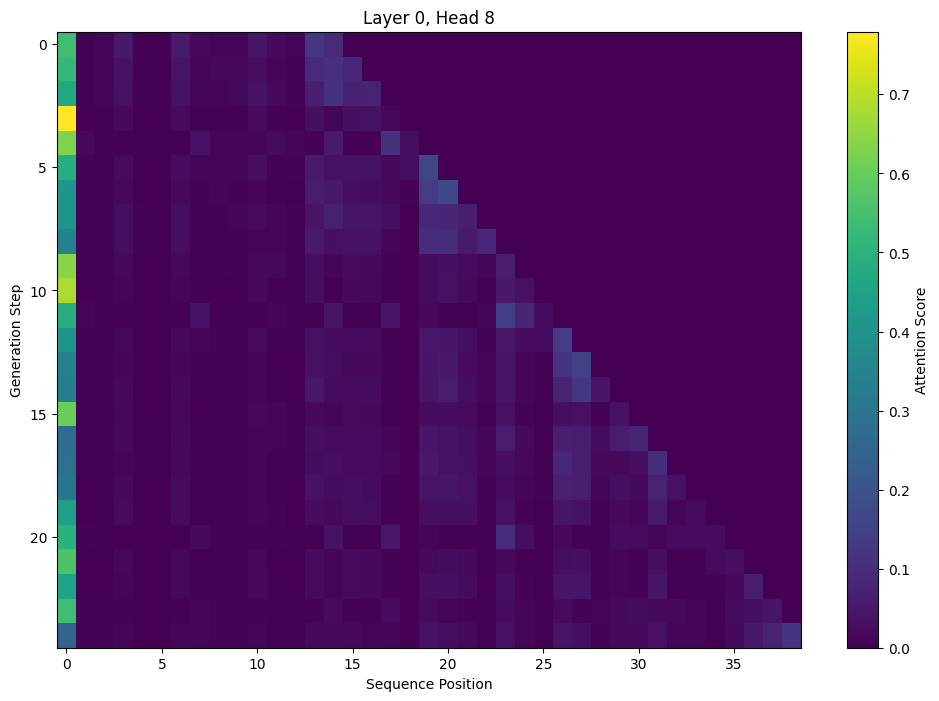

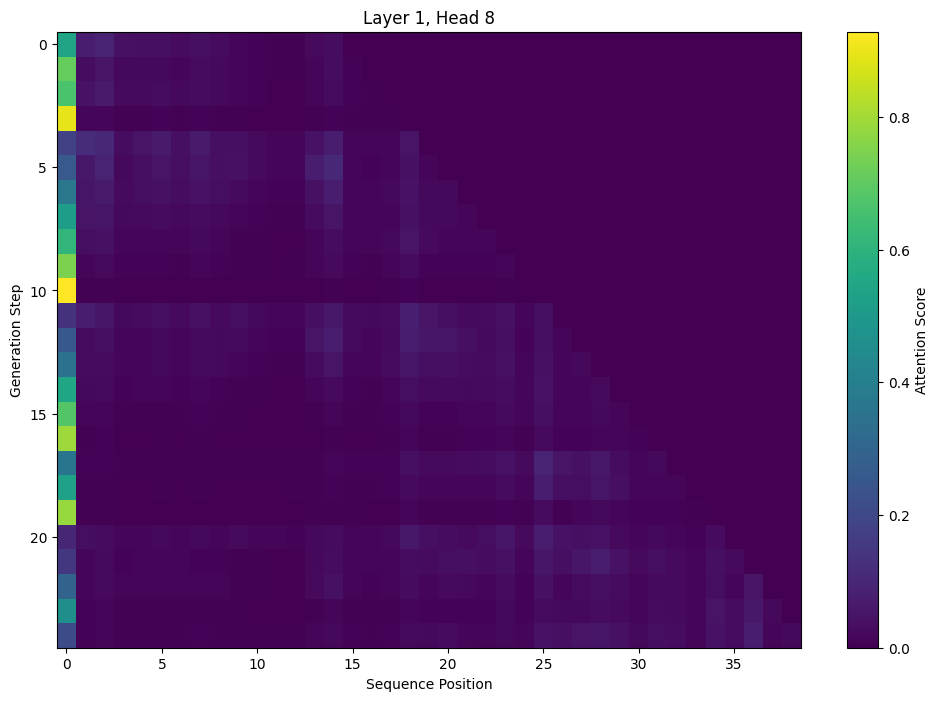

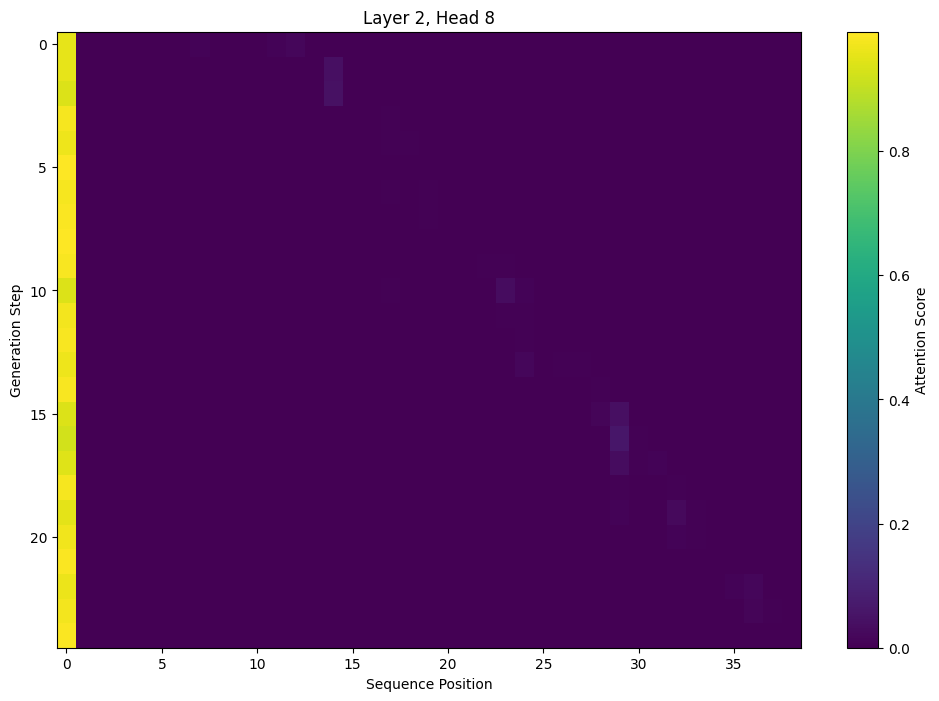

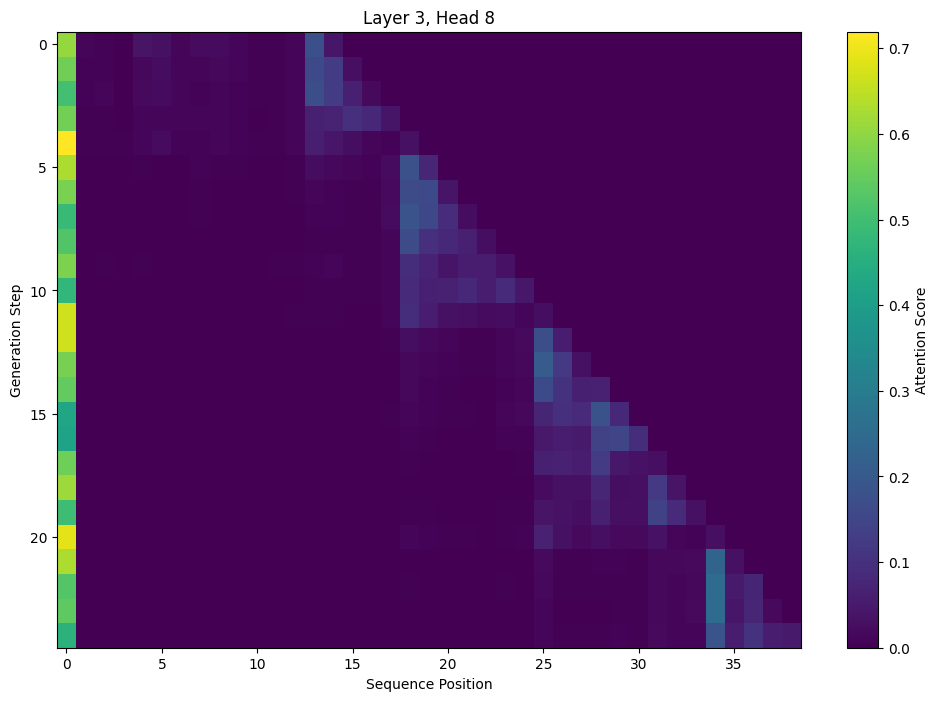

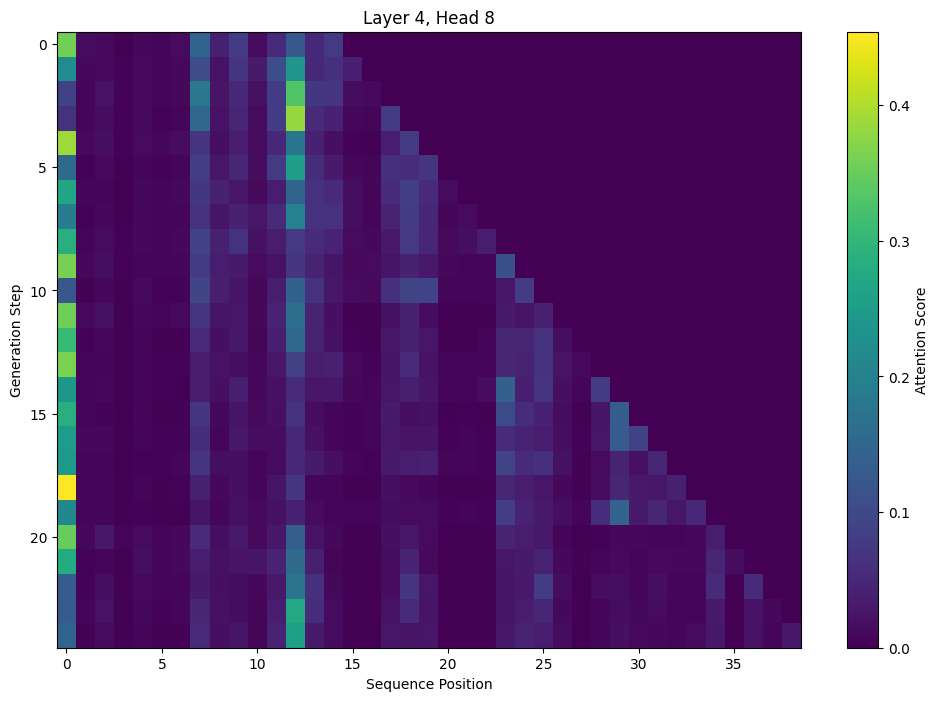

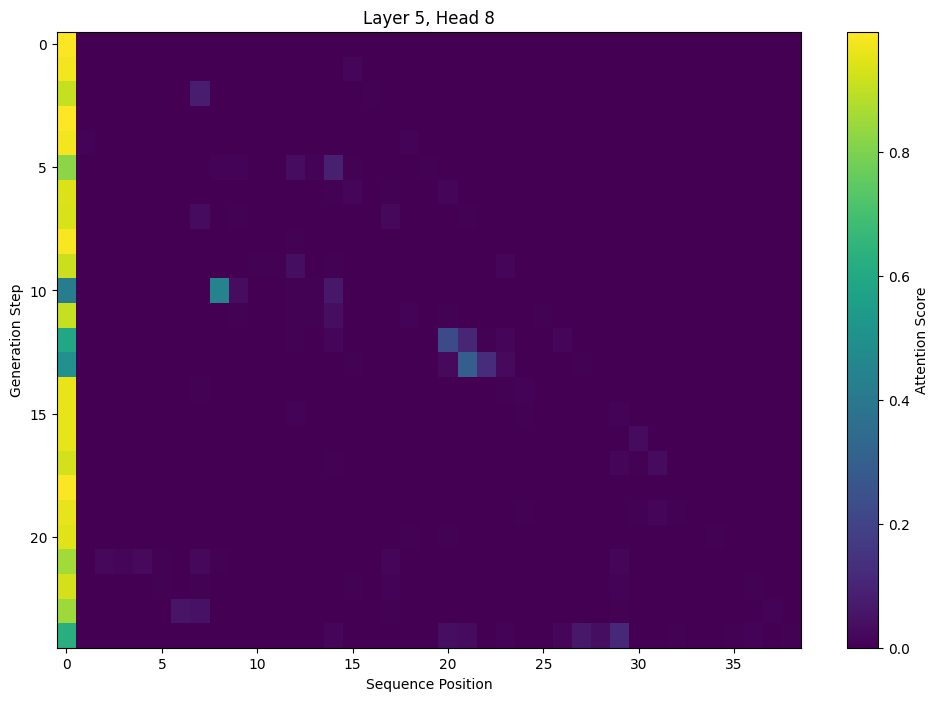

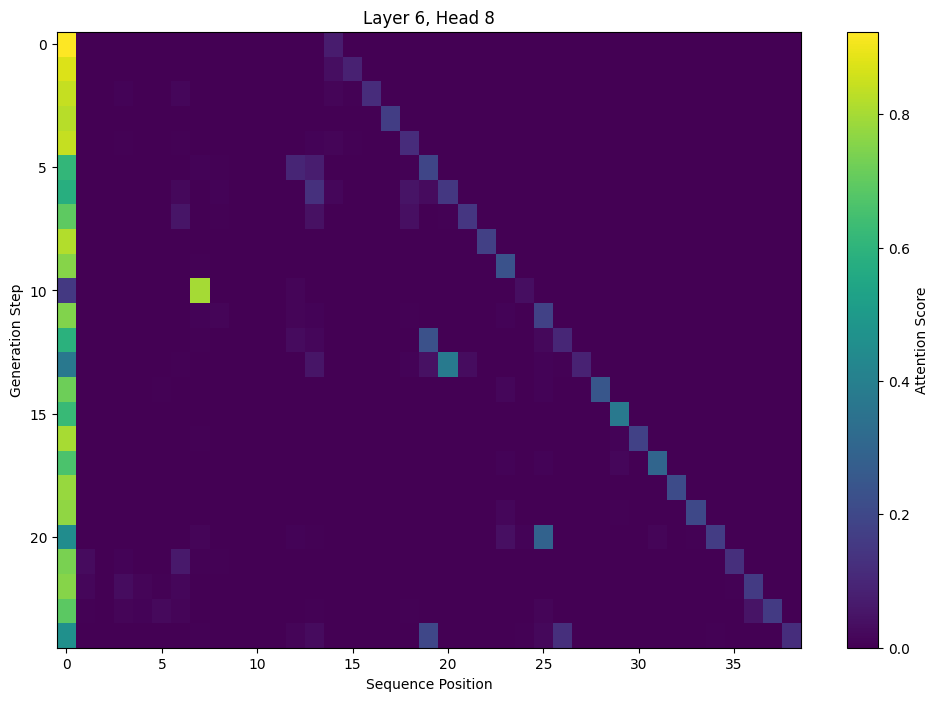

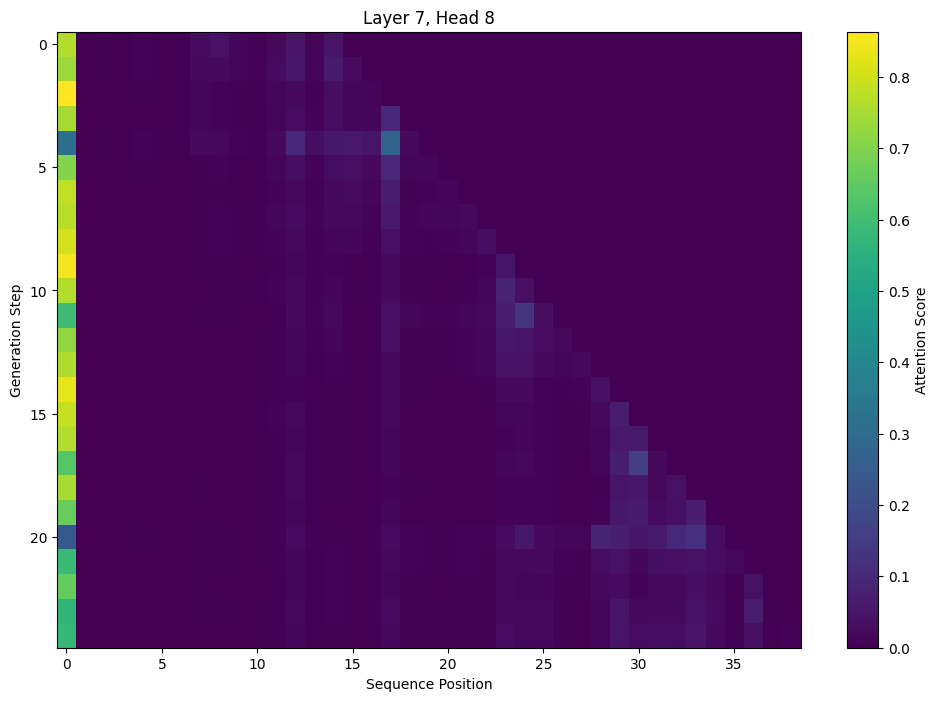

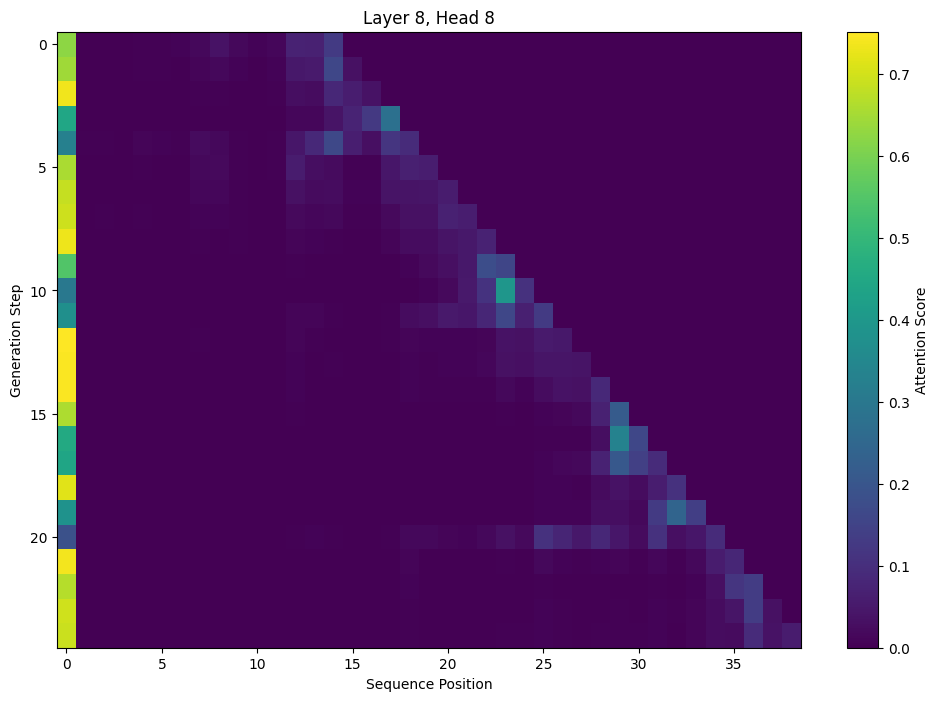

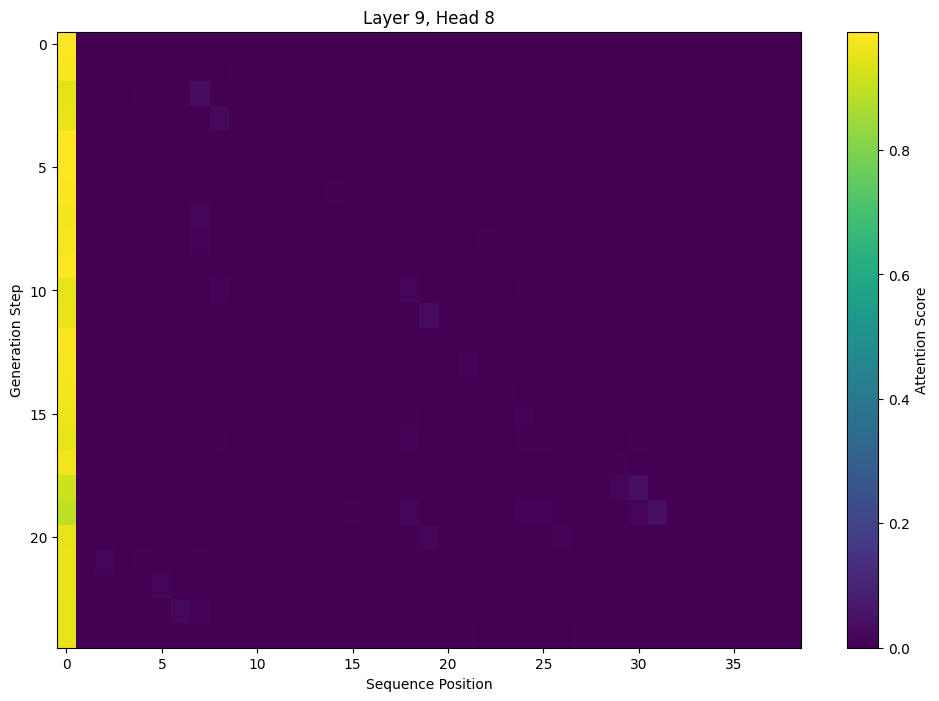

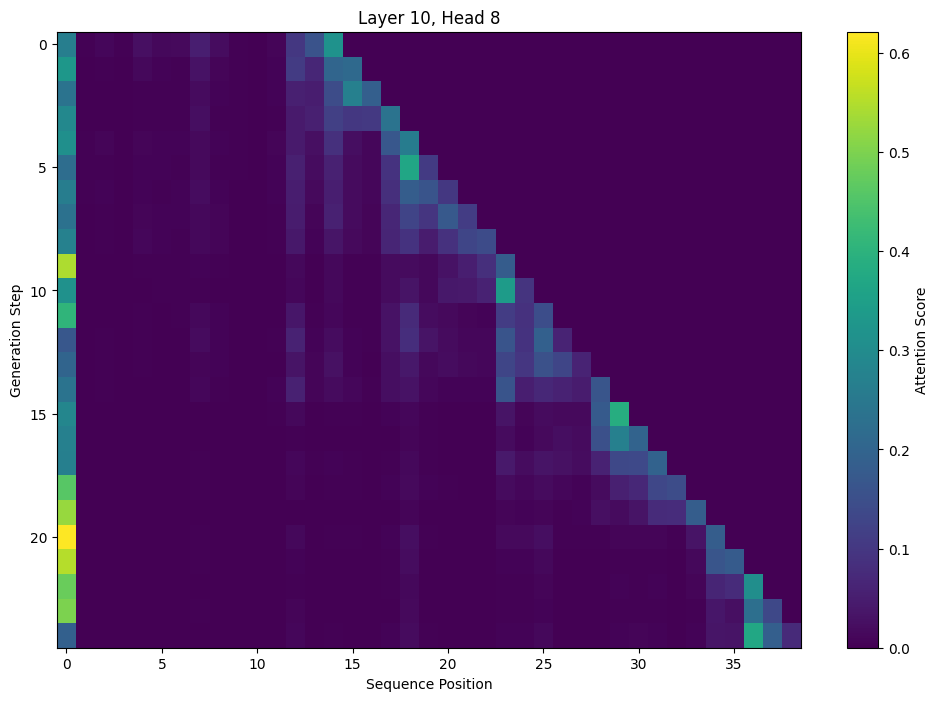

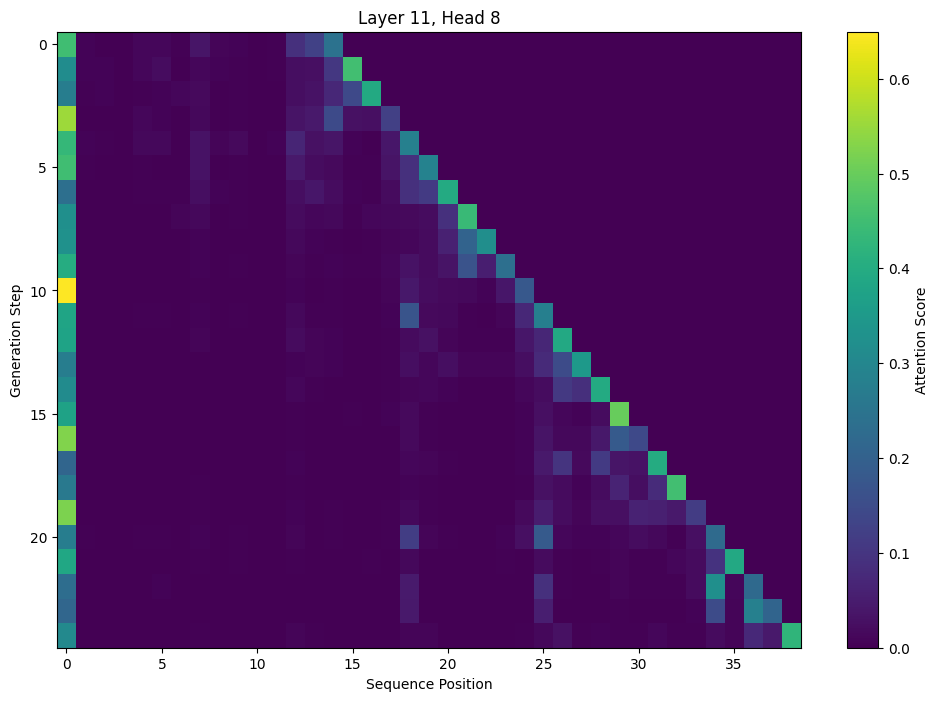

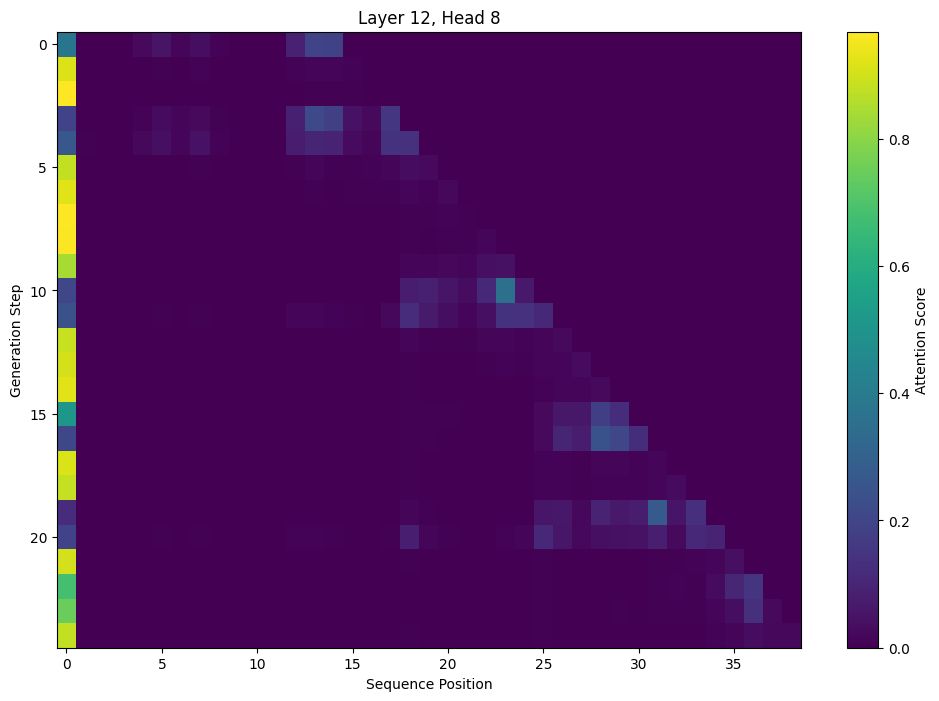

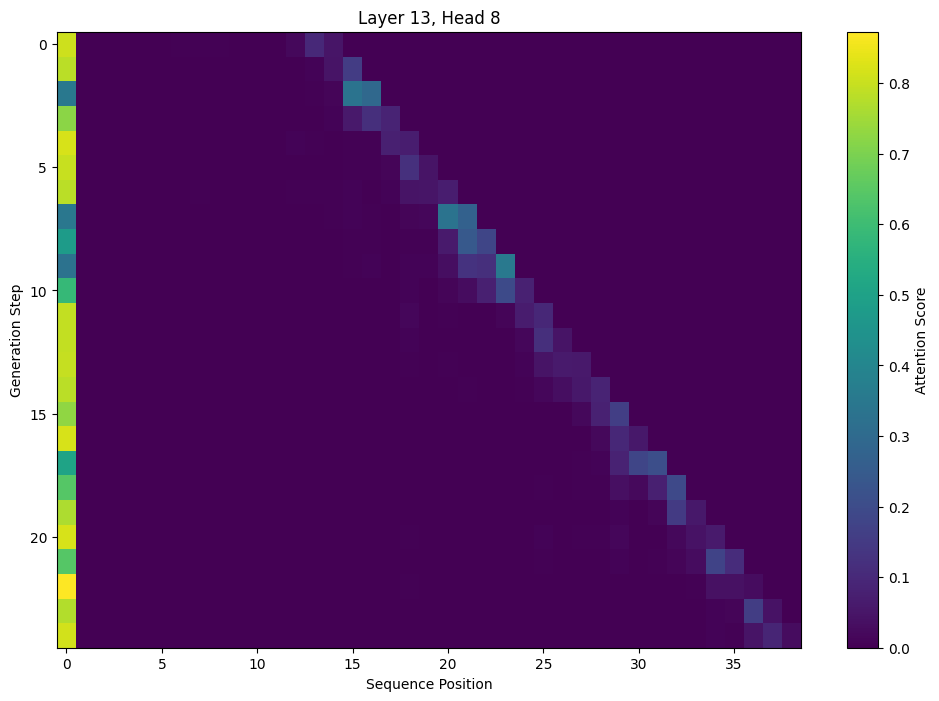

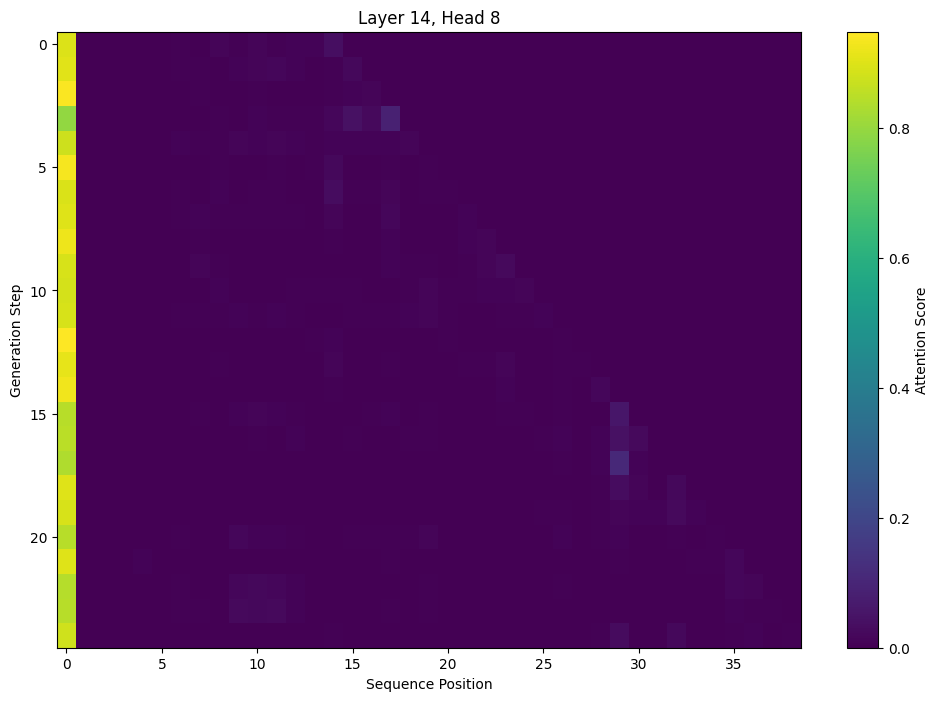

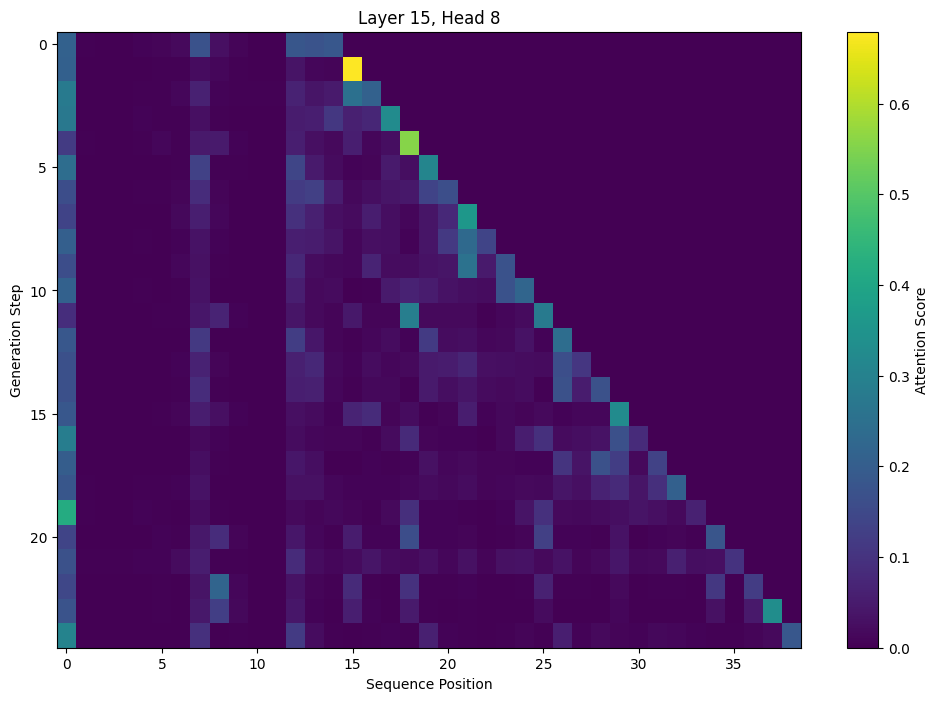

In [ ]:
# Parameters
import numpy as np

max_seq_len = 40
specified_head = 8  # Intermediate head index
eos_token_id = tokenizer.eos_token_id

# Initialize lists to collect attention scores for each layer
attention_scores_per_layer = {i: [] for i in range(len(model.model.layers))}

# Token generation loop
while len(input_ids[0]) < max_seq_len:
    with torch.no_grad():
        outputs = model(input_ids, attention_mask=attention_mask, output_attentions=True)
    logits = outputs.logits[:, -1, :]
    next_token = torch.argmax(logits, dim=-1)
    if next_token.item() == eos_token_id:
        break
    # Collect attention scores for the last token in the sequence for each layer and specified head
    for layer_idx, attentions in enumerate(outputs.attentions):
        # attentions shape: (1, num_heads, seq_len, seq_len)
        # Get attention scores for the specified head and last token
        seq_len = len(input_ids[0])
        attention_scores = attentions[0, specified_head, -1, :seq_len].detach().cpu().numpy()
        attention_scores_per_layer[layer_idx].append(attention_scores)
    # Append the next token to input_ids and attention_mask
    input_ids = torch.cat([input_ids, next_token.unsqueeze(0)], dim=1)
    attention_mask = torch.cat([attention_mask, torch.ones(1, 1)], dim=1)
    if len(input_ids[0]) >= max_seq_len:
        break

# Plotting attention scores as heatmaps
num_layers = len(model.model.layers)
for layer_idx in range(num_layers):
    # Get the attention scores for this layer
    scores = attention_scores_per_layer[layer_idx]
    # Pad shorter steps with zeros to match the maximum sequence length
    max_step_seq_len = len(scores[-1])  # Last step has the longest sequence
    padded_scores = []
    for step_scores in scores:
        padding = max_step_seq_len - len(step_scores)
        padded_scores.append(np.pad(step_scores, (0, padding), mode='constant'))
    # Convert to a matrix for heatmap
    heatmap_data = np.array(padded_scores)
    plt.figure(figsize=(12, 8))
    plt.imshow(heatmap_data, aspect='auto', cmap='viridis')
    plt.xlabel('Sequence Position')
    plt.ylabel('Generation Step')
    plt.title(f'Layer {layer_idx}, Head {specified_head}')
    plt.colorbar(label='Attention Score')
    plt.show()

# Dataset test

In [ ]:
tag = 1
inputs = []
# # use dataset to generate prompts
# # chose a dataset
# from datasets import load_dataset
# dataset = load_dataset("wikihow", "all")
# prompts = dataset["headline"][:10]
# # Tokenize the prompts
# for prompt in prompts:
#     inputs.append(tokenizer.encode(prompt, return_tensors="pt"))

## Rubbish codes

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt

# # Generate output with attention for tag 0, i.e., only one input
# output = model(input_ids, output_attentions=True)
# attentions = output.attentions

# # Extract attention maps for the first num_tokens generated tokens
# num_tokens = 4
# attention_maps = [attn[0, :, :num_tokens, :num_tokens].detach().numpy() for attn in attentions]

# # Print some metrics
# print(f"Number of layers: {len(attention_maps)}")
# print(f"Number of heads: {attention_maps[0].shape[0]}")
# print(f"Number of tokens: {num_tokens}")
# print(f"Dimensions of the attention maps: {attention_maps[0].shape}")

# # Print the input tokens
# tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
# print("Input tokens:", tokens)

# # Print the output tokens
# output_tokens = output.logits[0, -num_tokens:, :].argmax(dim=-1)
# output_tokens = tokenizer.convert_ids_to_tokens(output_tokens)
# print("Output tokens:", output_tokens)

# # Plot attention maps with distinct colors and borders
# fig, axes = plt.subplots(len(attention_maps), num_tokens, figsize=(15, 70))
# for i, layer_attention in enumerate(attention_maps):
#     for j in range(num_tokens):
#         ax = axes[i, j]
#         # Display attention for each head
#         for head in range(layer_attention.shape[0]):
#             cax = ax.matshow(layer_attention[head, j].reshape(1, -1), cmap='viridis')
#             ax.set_title(f'Head {head+1}', fontsize=10)
#             ax.set_xticks([])
#             ax.set_yticks([])
#             for spine in ax.spines.values():
#                 spine.set_edgecolor('black')
#                 spine.set_linewidth(1)
#         if j == 0:
#             ax.set_ylabel(f'Layer {i+1}', fontsize=15, rotation=0, labelpad=50)
# # Add colorbar horizontally at the bottom
# cbar_ax = fig.add_axes([0.15, -0.02, 0.7, 0.02])
# fig.colorbar(cax, cax=cbar_ax, orientation='horizontal')
# plt.tight_layout()
# plt.show()

# # Print metrics of the attention maps
# for i, layer_attention in enumerate(attention_maps):
#     print(f"Layer {i+1}")
#     for j in range(num_tokens):
#         print(f"Token {j+1}")
#         for head in range(layer_attention.shape[0]):
#             print(f"  Head {head+1}")
#             print("    Min:", np.min(layer_attention[head, j]))
#             print("    Max:", np.max(layer_attention[head, j]))
#             print("    Mean:", np.mean(layer_attention[head, j]))
#             print("    Std:", np.std(layer_attention[head, j]))
#             print()